# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:**  Meher Sidhu 
**`Roll Number`:**  U20230053
**`GitHub Branch`:** Meher_U20230053 


In [5]:
pip install rlcmab-sampler

Note: you may need to restart the kernel to use updated packages.


# Imports and Setup

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

from xgboost import XGBClassifier

from rlcmab_sampler import sampler


# Load Datasets

In [15]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())
print(train_users.head())


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


Classifier used is XGBoost because it is the industry standard for tabular data

In [23]:

X = train_users.drop(columns=["label", "user_id"]).copy()
y = train_users["label"]
X_final_test = test_users.drop(columns=["user_id"]).copy()

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

numeric_features = ["age", "income", "clicks", "purchase_amount", "session_duration", 
                    "content_variety", "engagement_score", "num_transactions", 
                    "avg_monthly_spend", "screen_brightness", "battery_percentage", 
                    "cart_abandonment_count", "background_app_count", 
                    "session_inactivity_duration", "network_jitter"]

numeric_features = [c for c in numeric_features if c in X.columns]
categorical_features = [c for c in X.columns if c not in numeric_features]

def to_string(x):
    return pd.DataFrame(x).astype(str)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("to_str", FunctionTransformer(to_string)), # Fixes the version number error
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

clf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb", XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42))
])

clf_pipeline.fit(X_train, y_train)
val_accuracy = clf_pipeline.score(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy:.4f}")

test_preds_numeric = clf_pipeline.predict(X_final_test)
test_preds_labels = le.inverse_transform(test_preds_numeric) # Convert back to original strings

Validation Accuracy: 0.9050


# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


In [13]:
reward_sampler = sampler(53)
reward = reward_sampler.sample(3)
print(reward)

0.09801194253265866


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [28]:
print(news_df["category"].unique())

<StringArray>
[     'U.S. NEWS',         'COMEDY',      'PARENTING',     'WORLD NEWS',
 'CULTURE & ARTS',           'TECH',         'SPORTS',  'ENTERTAINMENT',
       'POLITICS',     'WEIRD NEWS',    'ENVIRONMENT',      'EDUCATION',
          'CRIME',        'SCIENCE',       'WELLNESS',       'BUSINESS',
 'STYLE & BEAUTY',   'FOOD & DRINK',          'MEDIA',   'QUEER VOICES',
  'HOME & LIVING',          'WOMEN',   'BLACK VOICES',         'TRAVEL',
          'MONEY',       'RELIGION',  'LATINO VOICES',         'IMPACT',
       'WEDDINGS',        'COLLEGE',        'PARENTS', 'ARTS & CULTURE',
          'STYLE',          'GREEN',          'TASTE', 'HEALTHY LIVING',
  'THE WORLDPOST',      'GOOD NEWS',      'WORLDPOST',          'FIFTY',
           'ARTS',        'DIVORCE']
Length: 42, dtype: str


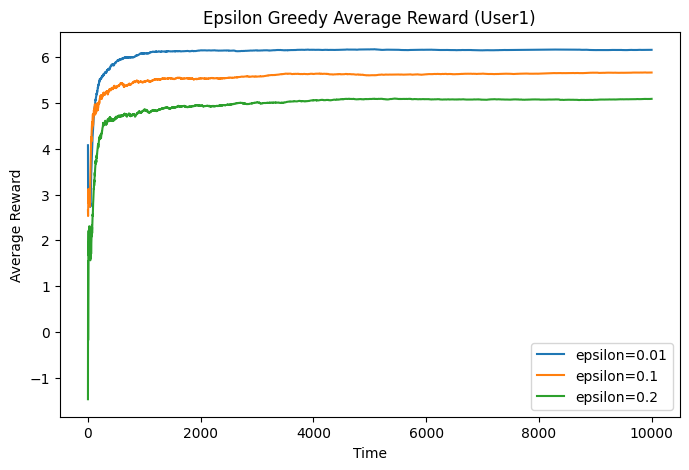

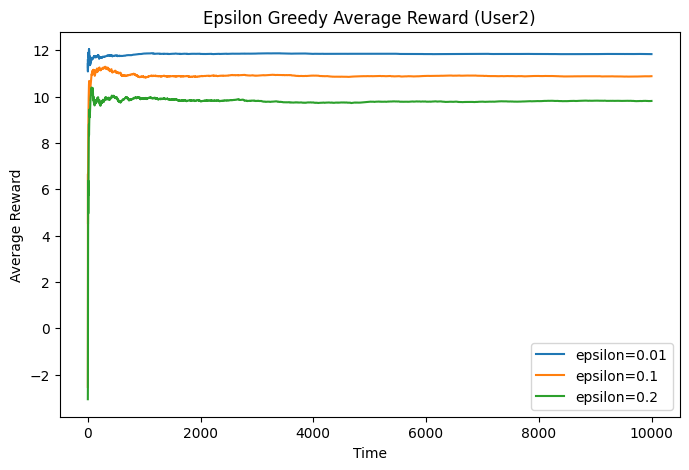

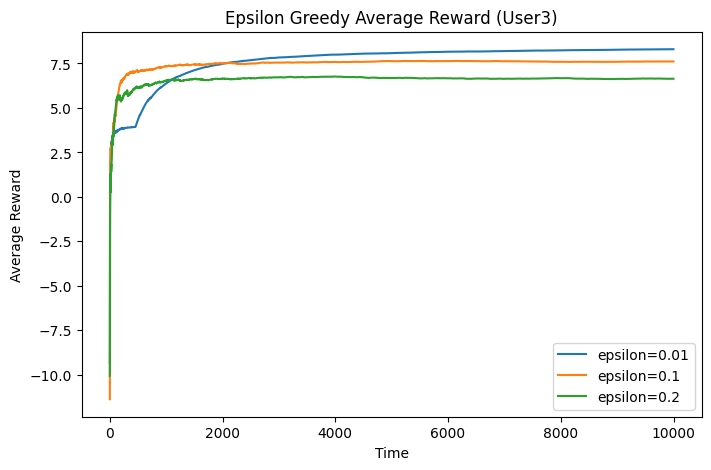

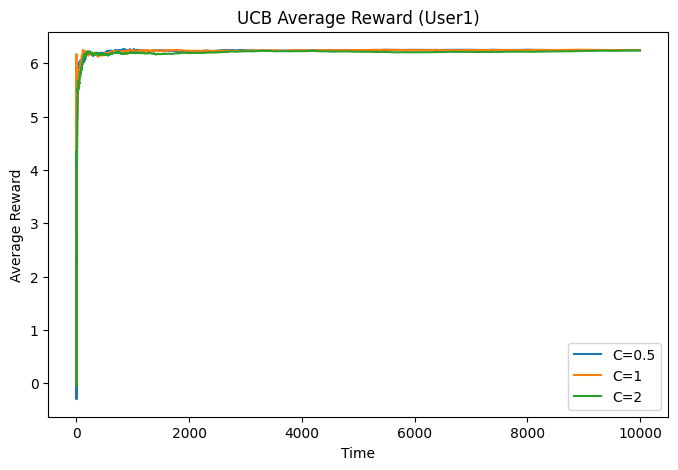

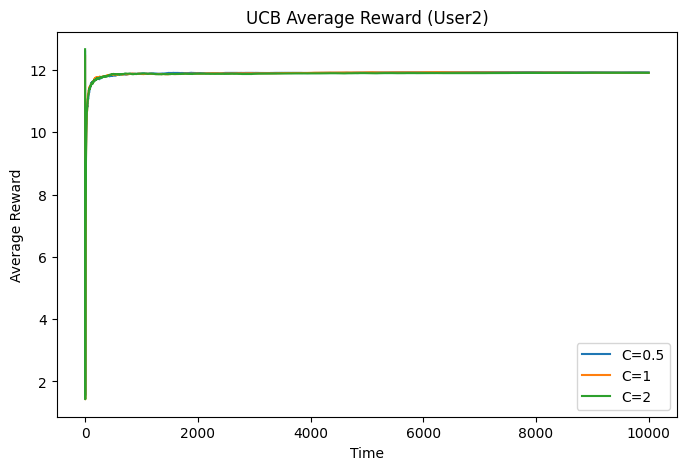

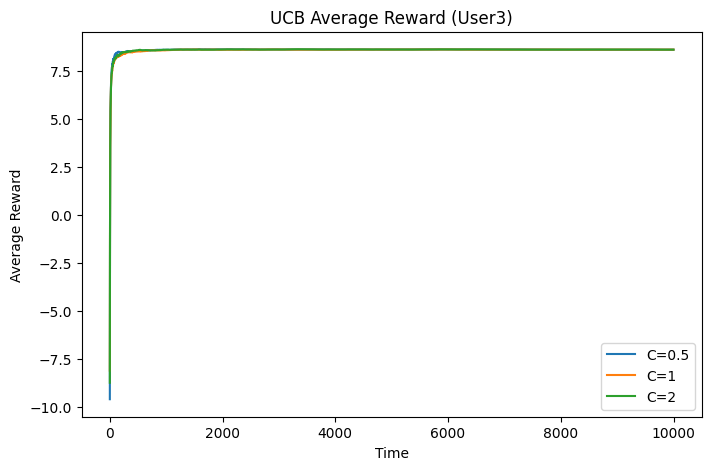

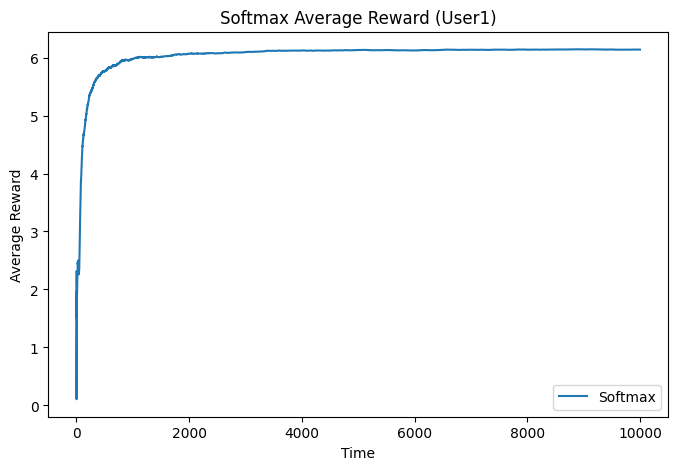

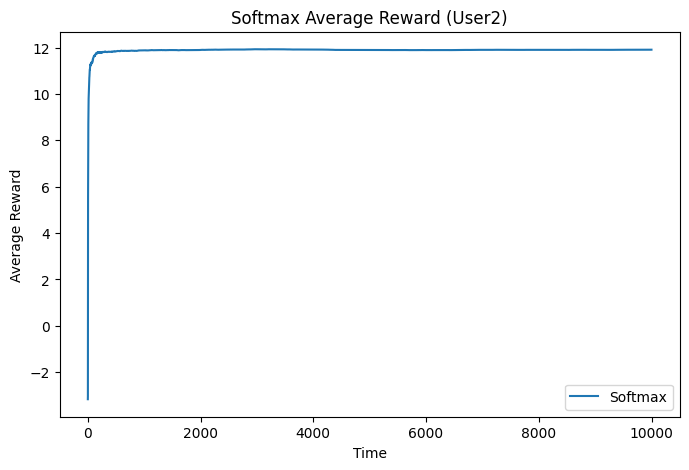

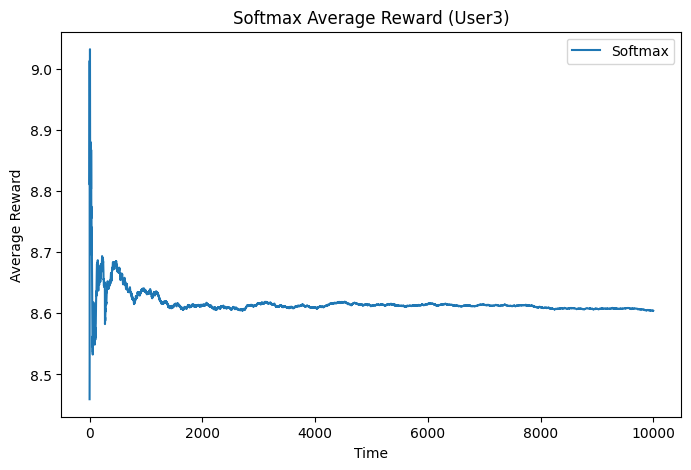


Expected Reward Distribution

User1
Entertainment Expected Reward: 2.9247722817383104
Education Expected Reward: 6.250734293703255
Tech Expected Reward: -5.523583307232764
Crime Expected Reward: -1.9038457706027907

User2
Entertainment Expected Reward: 11.90751307353109
Education Expected Reward: -0.9765873536669855
Tech Expected Reward: -1.95971490634139
Crime Expected Reward: -2.2295862098462527

User3
Entertainment Expected Reward: -10.136770731614284
Education Expected Reward: 3.9146125492278245
Tech Expected Reward: -8.10441392292561
Crime Expected Reward: 8.625464642785863

Predicted Context: User3
Recommended Category: Crime

Recommended Article

                                                    link  \
11307  https://www.huffingtonpost.com/entry/catholic-...   

                                                headline  category  \
11307  Pennsylvania Diocese Releases Names Of 51 Cler...  RELIGION   

                                       short_description          authors  

In [ ]:

ccategories = ["ENTERTAINMENT","EDUCATION","TECH","CRIME"]
news_df["category"] = news_df["category"].str.upper()


# Arm Mapping

def get_arm(context, category_index):

    context_map = {"User1":0,"User2":1,"User3":2}

    return context_map[context]*4 + category_index

# Incremental Update


def update_estimates(Q,N,arm,reward):

    N[arm]+=1
    Q[arm]+= (reward-Q[arm]) / N[arm]


# Epsilon Greedy

def epsilon_greedy(context,epsilon,T=10000):

    Q=np.zeros(4)
    N=np.zeros(4)

    rewards=[]

    for t in range(T):

        if np.random.rand() < epsilon:
            arm=np.random.randint(4)
        else:
            arm=np.argmax(Q)

        j=get_arm(context,arm)

        reward=reward_sampler.sample(j)

        update_estimates(Q,N,arm,reward)

        rewards.append(reward)

    return np.array(rewards),Q


# UCB


def ucb(context,C=1,T=10000):

    Q=np.zeros(4)
    N=np.zeros(4)

    rewards=[]

    for t in range(1,T+1):

        if 0 in N:
            arm=np.argmin(N)

        else:
            ucb_values=Q + C*np.sqrt(np.log(t)/N)
            arm=np.argmax(ucb_values)

        j=get_arm(context,arm)

        reward=reward_sampler.sample(j)

        update_estimates(Q,N,arm,reward)

        rewards.append(reward)

    return np.array(rewards),Q


# Softmax

def softmax_bandit(context,tau=1,T=10000):

    Q=np.zeros(4)
    N=np.zeros(4)

    rewards=[]

    for t in range(T):

        exp_q=np.exp(Q/tau)

        probs=exp_q/np.sum(exp_q)

        arm=np.random.choice(np.arange(4),p=probs)

        j=get_arm(context,arm)

        reward=reward_sampler.sample(j)

        update_estimates(Q,N,arm,reward)

        rewards.append(reward)

    return np.array(rewards),Q


# Run Simulations


T=10000

epsilons=[0.01,0.1,0.2]
Cs=[0.5,1,2]

eps_results={}
ucb_results={}
softmax_results={}

for context in contexts:

    eps_results[context]={}
    ucb_results[context]={}

    for eps in epsilons:

        rewards,_=epsilon_greedy(context,eps,T)
        eps_results[context][eps]=rewards

    for C in Cs:

        rewards,_=ucb(context,C,T)
        ucb_results[context][C]=rewards

    rewards,_=softmax_bandit(context,1,T)
    softmax_results[context]=rewards



# Average Reward Plot Function

def plot_avg_reward(rewards,label):

    avg=np.cumsum(rewards)/(np.arange(len(rewards))+1)

    plt.plot(avg,label=label)


# Plot Epsilon Greedy


for context in contexts:

    plt.figure(figsize=(8,5))

    for eps in epsilons:

        plot_avg_reward(eps_results[context][eps],f"epsilon={eps}")

    plt.title(f"Epsilon Greedy Average Reward ({context})")
    plt.xlabel("Time")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.show()


# Plot UCB


for context in contexts:

    plt.figure(figsize=(8,5))

    for C in Cs:

        plot_avg_reward(ucb_results[context][C],f"C={C}")

    plt.title(f"UCB Average Reward ({context})")
    plt.xlabel("Time")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.show()


# Softmax Plot


for context in contexts:

    plt.figure(figsize=(8,5))

    plot_avg_reward(softmax_results[context],"Softmax")

    plt.title(f"Softmax Average Reward ({context})")
    plt.xlabel("Time")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.show()


# Expected Reward Distribution


print("\nExpected Reward Distribution\n")

for context in contexts:

    rewards,Q=epsilon_greedy(context,0.1,T)

    print(context)

    for i,cat in enumerate(categories):

        print(cat,"Expected Reward:",Q[i])

    print()


user_classifier = clf_pipeline


# Select best category using bandit


def select_category(context):

    rewards, Q = epsilon_greedy(context, 0.1, 5000)

    best_arm = np.argmax(Q)

    return categories[best_arm]



# Context mapping
context_label_map = {0:"User1",1:"User2",2:"User3"}



# Recommendation Engine


def recommend_article(user_features):

    context_num = user_classifier.predict(user_features)[0]

    if isinstance(context_num, (int, np.integer)):
        context = context_label_map[context_num]
    else:
        context = context_num

    category = select_category(context)

    filtered = news_df[news_df["category"] == category]

    if filtered.empty:
        article = news_df.sample(1)
    else:
        article = filtered.sample(1)

    return context, category, article

# Test Recommendation Engine

sample_user = test_users.iloc[[0]]

context, category, article = recommend_article(sample_user)

print("Predicted Context:", context)
print("Recommended Category:", category)

print("\nRecommended Article\n")
print(article)

# Test Recommendation Engine


sample_user=test_users.iloc[[0]]

context,category,article=recommend_article(sample_user)

print("Predicted Context:",context)
print("Recommended Category:",category)

print("\nRecommended Article\n")

print(article)

## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach
